In [39]:
import glob
import os
import pandas as pd
import regex_search
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
path = "../DataPreprocessing/outputs/chunks"# Get all pickle files
files = sorted(glob.glob(os.path.join(path, "*.pkl")))
dfs = []
for f in files:
    print("Reading:", os.path.basename(f))
    dfs.append(pd.read_pickle(f))# Combine into a single dataframe
df_combined = pd.concat(dfs, ignore_index=True)
print("Done! Total rows:", len(df_combined))

Reading: cleaned_courses_final_chunk_1.pkl
Reading: cleaned_courses_final_chunk_10.pkl
Reading: cleaned_courses_final_chunk_11.pkl
Reading: cleaned_courses_final_chunk_12.pkl
Reading: cleaned_courses_final_chunk_13.pkl
Reading: cleaned_courses_final_chunk_14.pkl
Reading: cleaned_courses_final_chunk_15.pkl
Reading: cleaned_courses_final_chunk_16.pkl
Reading: cleaned_courses_final_chunk_17.pkl
Reading: cleaned_courses_final_chunk_18.pkl
Reading: cleaned_courses_final_chunk_19.pkl
Reading: cleaned_courses_final_chunk_2.pkl
Reading: cleaned_courses_final_chunk_20.pkl
Reading: cleaned_courses_final_chunk_21.pkl
Reading: cleaned_courses_final_chunk_22.pkl
Reading: cleaned_courses_final_chunk_23.pkl
Reading: cleaned_courses_final_chunk_24.pkl
Reading: cleaned_courses_final_chunk_25.pkl
Reading: cleaned_courses_final_chunk_26.pkl
Reading: cleaned_courses_final_chunk_27.pkl
Reading: cleaned_courses_final_chunk_28.pkl
Reading: cleaned_courses_final_chunk_29.pkl
Reading: cleaned_courses_final_chu

In [41]:
df_combined['is_ug'] = df_combined['cat_type'] == 'ug'
df_combined['is_gr'] = df_combined['cat_type'] == 'gr'
df_combined['is_both'] = df_combined['cat_type'] == 'both'

df_combined['full_description'] = df_combined['Title'] + ' ' + df_combined['Description']
df_combined['full_description'] = df_combined['full_description'].astype(str)
df_combined['full_description'] = df_combined['full_description'].apply(lambda x: x.lower())
df_combined.head()

,ipeds_id,cat_type,start_yr,end_yr,page_num,col_num,type,annote_id,Department,Number,...,quinquennium,DepartmentCleaned,id_catalog,id_course,id_dep_code,id_department_course,is_ug,is_gr,is_both,full_description
0,166638,ug,1999,2000,176,0,courses,757270,cmps,1999,...,1995,cmps,166638_ug_1999_2000,1999_Seeclel Topics,cmps_1999,cmps_Seeclel Topics,True,False,False,seeclel topics this course is part of the expe...
1,200280,gr,1960,1961,47,0,courses,804714,art,506,...,1960,art,200280_gr_1960_1961,506_Artist'S Techniques,art_506,art_Artist'S Techniques,False,True,False,artist's techniques instruction in the prepara...
2,200280,both,2001,2003,145,0,courses,742474,nutr,241,...,2000,nutr,200280_both_2001_2003,241_Maternal And Child Nutrition,nutr_241,nutr_Maternal And Child Nutrition,False,False,True,maternal and child nutrition investigation and...
3,200280,ug,1964,1966,363,0,courses,806302,social work,447,...,1960,social work,200280_ug_1964_1966,447_Field Practice,social work_447,social work_Field Practice,True,False,False,"field practice experience in interviewing, pla..."
4,166638,ug,1974,1975,160,2,courses,765273,edel,311,...,1970,edel,166638_ug_1974_1975,311_The Child And The Curriculum,edel_311,edel_The Child And The Curriculum,True,False,False,the child and the curriculum elementary (2) he...


In [42]:
queries = [
    "thinking machines",
    "turing",
    "neural networks",
    "symbolic reasoning",
    "logic theorist",
    "cognitive revolution",
    "natural language processing",
    "natural language",
    "algorithm",
    "machine vision",
    "turing machine",
    "unsupervised learning",
    "a\.i\.",
    "semi-supervised learning",
    "reinforcement learning",
    "computational intelligence",
    "automata",
    "evolutionary computation",
    "bayesian networks"
]
obj = regex_search.KeyWordListSearchAgent(queries, courses_df=df_combined)

# Full dataset

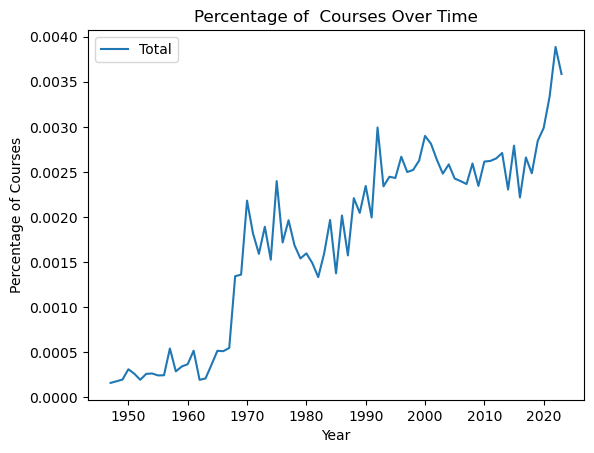

In [44]:
time_series_results = obj.time_series(show_by_type=False)

# Three schools

Starting UCLA.
UCLA completed.
Starting UVM.
UVM completed.
Starting North Dakota.
North Dakota completed.


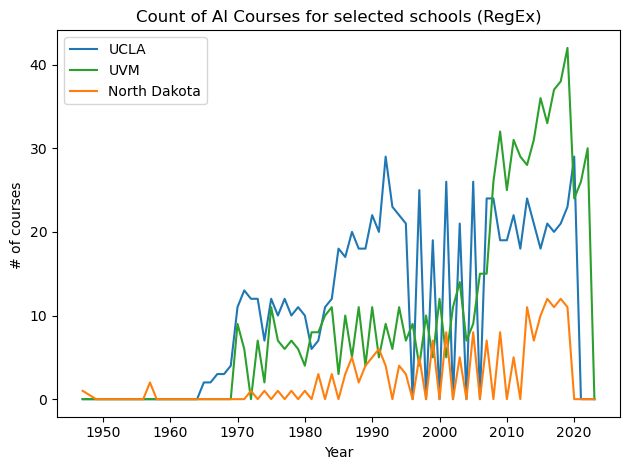

In [45]:
test_ids = ['110662', '231174', '200280']
labels = ['UCLA', 'UVM', 'North Dakota']
colors = ['tab:blue', 'tab:green', 'tab:orange']

for i in range(0,3):
    print(f'Starting {labels[i]}.')
    series = obj.time_series(percentage=False, show=False, category='AI', IPEDS=test_ids[i])
    plt.plot(series['Years'], series['total_percent'], c=colors[i], label = labels[i])
    print(labels[i] + " completed.")

plt.title('Count of AI Courses for selected schools (RegEx)')
plt.ylabel('# of courses ')
plt.xlabel('Year')
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrix

In [37]:
uvm_df = pd.read_excel('../data/uvm_ground_truth 1.xlsx')
ucla_df = pd.read_excel('../data/ucla_ground_truth 1.xlsx')
und_df = pd.read_excel('../data/und_ground_truth 1.xlsx')

ground_truth_df = pd.concat([uvm_df, ucla_df, und_df])

ground_truth_df['is_ug'] = ground_truth_df['cat_type'] == 'ug'
ground_truth_df['is_gr'] = ground_truth_df['cat_type'] == 'gr'
ground_truth_df['is_both'] = ground_truth_df['cat_type'] == 'both'

ground_truth_df['full_description'] = ground_truth_df['Title'] + ' ' + ground_truth_df['Description']
ground_truth_df['full_description'] = ground_truth_df['full_description'].astype(str)
ground_truth_df['full_description'] = ground_truth_df['full_description'].apply(lambda x: x.lower())

obj2 = regex_search.KeyWordListSearchAgent(queries, courses_df=ground_truth_df)

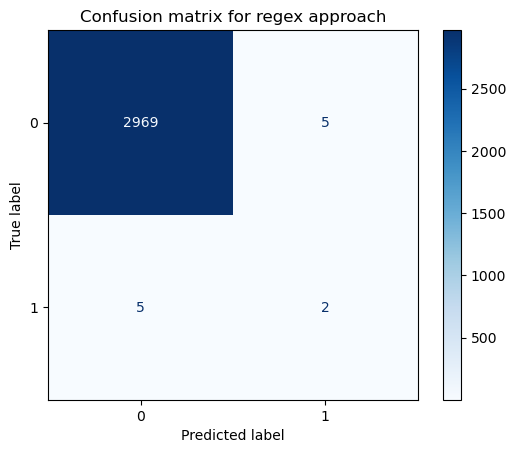

In [38]:
from sklearn.metrics import confusion_matrix

test_df = obj2.full_df

confused = confusion_matrix(test_df['has_ai'], test_df['any_keyword_present'])

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create the display object
disp = ConfusionMatrixDisplay(confusion_matrix=confused)

# Plot the matrix
disp.plot(cmap='Blues')
plt.title('Confusion matrix for regex approach')
plt.show()
